In [1]:
# KaiWang V-0417-01
%load_ext autoreload
%autoreload 2
import pandas as pd 
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import ipywidgets as widgets
from chinese_calendar import is_holiday, is_workday, is_in_lieu
from chinese_calendar import get_holidays
from dotenv import load_dotenv
import seaborn as sns 
import matplotlib.pyplot as plt
import subprocess
from concurrent.futures import ThreadPoolExecutor,ProcessPoolExecutor, as_completed
from typing import Dict, Iterable, Optional
from tqdm import tqdm
import requests
from pathlib import Path
import shutil
import json
import os 
import re
import warnings
warnings.filterwarnings("ignore")

import HelperFunc as hfc
from HelperFunc import COLUMNS_SCORES # 常量：列名
from Prompt_Template import PromptTemplate

pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

science_colors = [
    '#0C5DA5', '#00B945', '#FF9500', '#FF2C00', 
    '#845B97', '#474747', '#9e9e9e'
]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=science_colors)
sns.set_palette(science_colors)

# 设置文件路径

In [2]:
ANALYSIS_DIR = r"..//Analysis"
DATA_DIR = r"..//Data"
PROCESSED_DATA_DIR = r"..//Processed_Data"
DELIVERABLES_DIR = r"..//Deliverables"
os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(DELIVERABLES_DIR, exist_ok=True)

# Folder
KINYO_DATA_FOLDER = os.path.join(DATA_DIR, "金运") # 金运数据文件夹
KINYO_DY_DAILY_PERF_DATA_FOLDER = os.path.join(KINYO_DATA_FOLDER, "抖音每日绩效数据") # 金运抖音数据文件夹
OCEANENGINE_DATA_FOLDER = os.path.join(DATA_DIR, "巨量千川") # 巨量千川数据文件夹
TECDO_DATA_FOLDER = os.path.join(DATA_DIR, "钛动科技") # 钛动科技数据文件夹
TECDO_GOOD_PERF_DATA_FOLDER = os.path.join(TECDO_DATA_FOLDER, "绩效表现好的视频文件") # 钛动科技绩效表现好的视频文件夹
TECDO_BAD_PERF_DATA_FOLDER = os.path.join(TECDO_DATA_FOLDER, "绩效表现差的视频文件") # 钛动科技绩效表现差的视频文件夹
K7_DATA_FOLDER = os.path.join(DATA_DIR, "K7视频素材") # K7视频素材文件夹
K7_GOOD_PERF_DATA_FOLDER = os.path.join(K7_DATA_FOLDER, "爆款") # K7绩效表现好的视频文件夹
K7_BAD_PERF_DATA_FOLDER = os.path.join(K7_DATA_FOLDER, "没啥动静") # K7绩效表现差的视频文件夹

MID_TERM_DIR = os.path.join(DELIVERABLES_DIR, "Mid-Term") # 中期文件夹
MID_TERM_CHARTS_DIR = os.path.join(MID_TERM_DIR, "Charts") # 中期图表文件夹
KNOWLEDGE_DIR = os.path.join(DELIVERABLES_DIR, "Knowledge") # 数据库文件夹
os.makedirs(MID_TERM_DIR, exist_ok=True)
os.makedirs(MID_TERM_CHARTS_DIR, exist_ok=True)
os.makedirs(KNOWLEDGE_DIR, exist_ok=True)

ENV_FILE = r"..//.env" # 环境变量文件路径
load_dotenv(ENV_FILE)

True

# 评价JSON文件文本化

In [3]:
# 将评价json转为txt文件
evaluation_json_files = [f for f in os.listdir(DATA_DIR) if f.endswith('.json')]
for json_file in evaluation_json_files:
    input_file = os.path.join(DATA_DIR, json_file)
    output_file = os.path.join(PROCESSED_DATA_DIR, json_file.replace('.json', '_compact.txt'))
    hfc.compress_json_to_txt(input_file, output_file)

已生成紧凑格式文件：..//Processed_Data\内容营销本体库_compact.txt
原始JSON字符数：24503
压缩后字符数：22299
节省了 2204 个字符 

已生成紧凑格式文件：..//Processed_Data\内容评价标准库_compact.txt
原始JSON字符数：6335
压缩后字符数：6008
节省了 327 个字符 

已生成紧凑格式文件：..//Processed_Data\内容评价标准库_v2_compact.txt
原始JSON字符数：13271
压缩后字符数：12574
节省了 697 个字符 

已生成紧凑格式文件：..//Processed_Data\内容评价标准库_v3_compact.txt
原始JSON字符数：6666
压缩后字符数：6262
节省了 404 个字符 

已生成紧凑格式文件：..//Processed_Data\内容评价标准库_v4_compact.txt
原始JSON字符数：6666
压缩后字符数：6262
节省了 404 个字符 



# 处理新的数据

In [4]:
# 新的数据
K7_DATA_EXCEL_PATH1 = os.path.join(K7_DATA_FOLDER,'1-2月份广告消耗数据天机-金运影音-声深未来-K7.xlsx')
K7_DATA_EXCEL_PATH2 = os.path.join(K7_DATA_FOLDER,'1-2月份广告消耗数据福州智星-华源-金运声研所-K7.xlsx')
k7_data_df = pd.concat([pd.read_excel(K7_DATA_EXCEL_PATH1), pd.read_excel(K7_DATA_EXCEL_PATH2)], ignore_index=True, axis = 0).reset_index(drop=True)
display(k7_data_df.head())

,素材名称,素材ID,素材评估,素材时长,素材创建时间,素材来源,标签,净成交ROI,整体展现次数,整体点击次数,整体点击率,整体转化率,整体支付ROI,整体点击单价,整体千次展现费用,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,视频完播率,整体消耗,基础消耗,整体成交金额,整体成交订单数,整体成交订单成本,用户实际支付金额,智能优惠券金额,电商平台补贴金额,整体未完结预售订单预估金额,净成交金额,净成交订单数,净成交订单成本,用户实际支付净成交金额,智能优惠券未退款金额,电商平台补贴未退款金额,净成交金额结算率,净成交订单结算率,1小时内退款订单数,1小时内退款金额,1小时内退款率
0,12月11日-K7-YL-(4)混剪.mp4,7582775222080798729,-,03:28,2026-01-12 22:31:50,本地上传,-,2.86,"6,226,514","178,289",2.86%,0.78%,3.41,2.09,59.97,31.67%,58.97%,42.33%,22.69%,"1,218","6,042,525","4,615","10,004",18.03,1.55%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2月10日-K7-CM- 混剪-.mp4,7600402383899377718,可提升,03:45,2026-02-10 16:58:00,本地上传,-,3.03,"1,755,674","65,382",3.72%,1.23%,3.65,3.17,118.02,28.46%,45.53%,34.49%,19.48%,248,"1,718,763","1,696","2,947",17.7,0.90%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AIGC动态创意素材集合,-,-,-,-,AIGC动态创意,-,3.51,"1,255,680","116,878",9.31%,0.66%,4.08,1.48,137.79,43.09%,59.70%,52.01%,34.73%,81,"1,172,248",0,0,0.0,9.19%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1月8日-K7-YL-混剪(7).mp4,7592938814681169958,-,04:12,2026-01-12 17:29:41,本地上传,-,2.67,"994,512","39,180",3.94%,1.30%,3.36,3.50,137.97,21.96%,37.86%,27.53%,14.30%,240,"1,028,384","1,181","1,770",14.91,0.68%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11月7日-K7-CM-混剪- (3)已发.mp4,7570125412971790346,优质,03:15,2026-01-14 09:00:25,本地上传,-,2.36,"840,769","26,641",3.17%,1.66%,3.04,5.13,162.58,43.00%,57.33%,49.24%,28.87%,199,"790,940",586,"1,500",18.01,1.65%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# 发现存在重复行， 同一个素材可能在不同的广告计划中投放，导致数据重复
duplicated_rows = k7_data_df[k7_data_df['素材ID'].duplicated(keep=False)].sort_values(by='素材ID')
display(duplicated_rows)

,素材名称,素材ID,素材评估,素材时长,素材创建时间,素材来源,标签,净成交ROI,整体展现次数,整体点击次数,整体点击率,整体转化率,整体支付ROI,整体点击单价,整体千次展现费用,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,视频完播率,整体消耗,基础消耗,整体成交金额,整体成交订单数,整体成交订单成本,用户实际支付金额,智能优惠券金额,电商平台补贴金额,整体未完结预售订单预估金额,净成交金额,净成交订单数,净成交订单成本,用户实际支付净成交金额,智能优惠券未退款金额,电商平台补贴未退款金额,净成交金额结算率,净成交订单结算率,1小时内退款订单数,1小时内退款金额,1小时内退款率
2,AIGC动态创意素材集合,-,-,-,-,AIGC动态创意,-,3.51,"1,255,680","116,878",9.31%,0.66%,4.08,1.48,137.79,43.09%,59.70%,52.01%,34.73%,81,"1,172,248",0,0,0.0,9.19%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2405,AIGC动态创意素材集合,-,-,-,-,AIGC动态创意,-,3.14,"1,725,158","88,139",5.11%,0.95%,3.90,2.19,111.87,44.29%,64.69%,55.27%,29.44%,126,"1,667,597",0,0,0.00,5.23%,"193,001.97","193,001.97","753,074.20",835,231.14,"727,368.05","16,307.79","9,398.36",0.0,"605,537.40",672,287.21,"583,821.91","13,603.73","8,111.76",80.41%,80.48%,163.0,"147,536.80",19.59%
39,8月28日-K7-MY- (3).mp4,7543777005557465138,优质,04:12,2026-01-28 11:22:06,本地上传,-,3.40,"71,811","4,539",6.32%,2.38%,3.85,5.98,378.02,45.62%,62.75%,55.03%,37.41%,14,"70,746",84,195,29.95,2.95%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2408,8月28日-K7-MY- (3).mp4,7543777005557465138,优质,04:12,2025-12-02 18:03:50,本地上传,-,3.26,"274,448","12,646",4.61%,3.08%,3.81,7.30,336.28,37.08%,65.09%,51.69%,26.69%,91,"264,006",414,678,18.87,1.56%,"92,291.68","89,550.38","351,210.80",389,237.25,"347,654.94","1,913.06","1,642.80",0.0,"300,866.90",333,277.15,"297,799.95","1,622.05","1,444.90",85.67%,85.60%,56.0,"50,343.90",14.33%
2510,9月9日-K7-MY- (8)已发.mp4,7548071818600546346,优质,01:49,2025-12-02 17:54:37,本地上传,-,3.57,"38,606","1,848",4.79%,1.68%,4.61,3.27,156.69,30.81%,51.82%,39.37%,21.05%,18,"39,775",54,67,14.01,4.97%,"6,049.23","6,049.23","27,869.00",31,195.14,"27,221.00",379.00,269.00,0.0,"21,576.00",24,252.05,"21,192.00",275.00,109.00,77.42%,77.42%,7.0,"6,293.00",22.58%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,2月25日-K7-MY- (2)已发.mp4,7610771446713630747,-,01:36,2026-02-25 20:00:38,本地上传,-,13.43,"2,328",62,2.66%,1.61%,13.43,1.08,28.76,18.17%,42.77%,28.79%,12.32%,2,"2,240",2,5,7.57,2.77%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1063,2月26日-K7-MY- (1).mp4,7611144167968915462,-,01:33,2026-02-26 20:07:04,本地上传,-,15.77,"6,037",103,1.71%,1.94%,15.77,1.11,18.89,19.97%,57.70%,34.26%,13.32%,1,"5,820",4,10,10.16,2.63%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3519,2月26日-K7-MY- (1)已发.mp4,7611144167968915462,-,01:33,2026-02-26 20:16:13,本地上传,-,0.00,"1,750",38,2.17%,0.00%,0.00,0.97,21.12,21.29%,60.59%,36.00%,14.22%,4,"1,639",2,2,11.70,4.03%,36.96,36.96,0.00,0,0.00,0.00,0.00,0.00,0.0,0.00,0,0.00,0.00,0.00,0.00,0.00%,0.00%,0.0,0.00,0.00%
3192,2月26日-K7-MY- (3)已发.mp4,7611144196593811510,-,01:27,2026-02-26 20:16:12,本地上传,-,0.00,"4,999",73,1.46%,0.00%,0.00,1.76,25.66,22.62%,54.18%,35.97%,14.21%,1,"4,771",3,9,8.13,2.08%,128.25,128.25,0.00,0,0.00,0.00,0.00,0.00,0.0,0.00,0,0.00,0.00,0.00,0.00,0.00%,0.00%,0.0,0.00,0.00%


In [6]:
# 新的视频路径
EXTERNAL_DATA_FOLDER = r"F:\KINYO\K7素材汇总"
# k7_video_folders = sorted([folder for folder in os.listdir(EXTERNAL_DATA_FOLDER) if not folder.endswith('.xlsx')], key = lambda x: int(re.findall(r'\d+', x)[0])) # 按照文件夹中的数字排序
# k7_video_df_list = []
# count = 0
# for level_1_folder in tqdm(k7_video_folders,desc = "Processing K7 video folders"):
#     for level_2_folder in os.listdir(os.path.join(EXTERNAL_DATA_FOLDER, level_1_folder)):
#         video_files = [file for file in os.listdir(os.path.join(EXTERNAL_DATA_FOLDER, level_1_folder, level_2_folder)) if file.endswith('.mp4')]
#         for video_file in video_files:
#             tmp_df = pd.DataFrame({
#                 "level_1_folder": level_1_folder,
#                 "level_2_folder": level_2_folder,
#                 "video_file": video_file,
#                 "video_path": os.path.join(EXTERNAL_DATA_FOLDER, level_1_folder, level_2_folder, video_file)
#             }, index=[count])
#             k7_video_df_list.append(tmp_df)
#             count += 1
# k7_video_df = pd.concat(k7_video_df_list, ignore_index=True)
# display(k7_video_df.head())

# # 数据处理
# k7_inner_merged_df = pd.merge(k7_data_df, k7_video_df,left_on = '素材名称', right_on = 'video_file', how = 'left').dropna(subset = 'video_file').reset_index(drop=True)
# k7_inner_merged_df_processed = k7_inner_merged_df[['素材名称','素材ID','素材创建时间','level_1_folder','level_2_folder','video_file','video_path']]
# # 素材时长 统一转化为秒
# time_fixed = '00:' + k7_inner_merged_df['素材时长'].astype(str)
# k7_inner_merged_df_processed['素材时长'] = pd.to_timedelta(time_fixed, errors='coerce').dt.total_seconds()
# # 普通数值列转为数值类型
# remove_comma_func = lambda x: str(x).replace(',', '') if isinstance(x, str) else x # function: 移除字符串中的逗号
# numeric_cols = ['净成交ROI','整体支付ROI','整体展现次数','整体点击次数','整体点击单价','整体千次展现费用', '视频评论数', '视频播放数',
#                 '新增粉丝数', '视频点赞数','平均观看时长','整体消耗', '基础消耗', '整体成交金额', '整体成交订单数', '整体成交订单成本',
#                 '用户实际支付金额', '智能优惠券金额', '电商平台补贴金额', '整体未完结预售订单预估金额', '净成交金额', '净成交订单数',
#                 '净成交订单成本', '用户实际支付净成交金额', '智能优惠券未退款金额', '电商平台补贴未退款金额','1小时内退款订单数']
# for col in numeric_cols:
#     k7_inner_merged_df_processed[col] = k7_inner_merged_df[col].apply(remove_comma_func).astype(float)
# # 百分率
# pct_cols = ['整体点击率', '整体转化率','5秒播放率', '2秒播放率', '3秒播放率', '10秒播放率','视频完播率','净成交金额结算率','净成交订单结算率','1小时内退款率']
# for col in pct_cols:
#     k7_inner_merged_df_processed[col] = k7_inner_merged_df[col].apply(lambda x: float(str(x).replace('%', '')) if isinstance(x, str) else np.nan)

# k7_inner_merged_df_processed = k7_inner_merged_df_processed.sort_values(by = ['2秒播放率', '3秒播放率','5秒播放率', '10秒播放率','视频完播率'],ascending = False).reset_index(drop=True)

# # 我发现之前处理好的k7_inner_merged_df_processed.xlsx文件中，素材ID有重复的情况，说明可能存在同一素材被多次投放的情况。
# # 因此做如下处理
# """
# 1. 素材名称, 素材ID, 保留
# 2. 素材创建时间,level_1_folder, level_2_folder, video_file, video_path 和素材时常保留最老的, 
# 3. 剩下的指标取平均值
# """

# ===== 按 素材ID 聚合去重 =====
KEY_COL = "素材ID"
CREATED_COL = "素材创建时间"

# if KEY_COL not in k7_inner_merged_df_processed.columns:
#     raise KeyError(f"缺少关键列 {KEY_COL!r}，现有列: {list(k7_inner_merged_df_processed.columns)}")

# df_raw = k7_inner_merged_df_processed.copy()
# if CREATED_COL in df_raw.columns:
#     df_raw[CREATED_COL] = pd.to_datetime(df_raw[CREATED_COL], errors="coerce")
#     df_raw["_created_sort"] = df_raw[CREATED_COL].fillna(pd.Timestamp.max)
# else:
#     df_raw["_created_sort"] = pd.Timestamp.max

# # 需要“保留最老记录”的列（如果列不存在会自动跳过）
# oldest_cols_priority = [
#     "素材名称",
#     CREATED_COL,
#     "level_1_folder",
#     "level_2_folder",
#     "video_file",
#     "video_path",
#     "素材时长",
#  ]
# oldest_cols = [c for c in oldest_cols_priority if c in df_raw.columns]

# # 其它列：能转成数值的做 mean；转不了的就从最老记录里带过去
# exclude_cols = set([KEY_COL, "_created_sort"] + oldest_cols)
# candidate_cols = [c for c in df_raw.columns if c not in exclude_cols]

# numeric_cols = []
# non_numeric_cols = []
# for c in candidate_cols:
#     s = df_raw[c]
#     if pd.api.types.is_numeric_dtype(s):
#         numeric_cols.append(c)
#         continue
#     s_num = pd.to_numeric(s, errors="coerce")
#     if s_num.notna().any():
#         df_raw[c] = s_num
#         numeric_cols.append(c)
#     else:
#         non_numeric_cols.append(c)

# # 1) 最老记录（提供 素材信息/路径/时长 + 以及无法数值化的列）
# oldest_rows = (
#     df_raw.sort_values([KEY_COL, "_created_sort"])
#     .groupby(KEY_COL, as_index=False)
#     .first()
# )
# keep_cols = [KEY_COL] + oldest_cols + non_numeric_cols
# keep_cols = [c for c in keep_cols if c in oldest_rows.columns]
# oldest_keep_df = oldest_rows.loc[:, keep_cols].copy()

# # 2) 指标列取平均
# if numeric_cols:
#     mean_df = df_raw.groupby(KEY_COL, as_index=False)[numeric_cols].mean()
# else:
#     mean_df = df_raw.loc[:, [KEY_COL]].drop_duplicates().copy()

# # 3) 合并
# k7_inner_merged_df_processed_dedup = oldest_keep_df.merge(mean_df, on=KEY_COL, how="left")

# # 清理并排序显示
# k7_inner_merged_df_processed_dedup = k7_inner_merged_df_processed_dedup.sort_values(by=[KEY_COL]).reset_index(drop=True)

# print("unique 素材ID:", k7_inner_merged_df_processed[KEY_COL].nunique(dropna=True))
# print("dedup rows:", len(k7_inner_merged_df_processed_dedup))
# print("raw duplicated 素材ID rows:", int(k7_inner_merged_df_processed[KEY_COL].duplicated(keep=False).sum()))
# print("dedup duplicated 素材ID rows:", int(k7_inner_merged_df_processed_dedup[KEY_COL].duplicated(keep=False).sum()))

# # 下游分析默认用去重后的表
# k7_inner_merged_df_processed = k7_inner_merged_df_processed_dedup.copy()

# # 保存去重后的结果
# k7_inner_merged_df_processed.to_excel(os.path.join(PROCESSED_DATA_DIR, "k7_inner_merged_df.xlsx"), index=False)
k7_inner_merged_df_processed = pd.read_excel(os.path.join(PROCESSED_DATA_DIR, "k7_inner_merged_df.xlsx"))

display(k7_inner_merged_df_processed.head())
display(k7_inner_merged_df_processed.describe())

print(f"是否不存在重复行了: {not k7_inner_merged_df_processed[KEY_COL].duplicated(keep=False).any()}")

,素材ID,素材名称,素材创建时间,level_1_folder,level_2_folder,video_file,video_path,素材时长,净成交ROI,整体支付ROI,整体展现次数,整体点击次数,整体点击单价,整体千次展现费用,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,整体消耗,基础消耗,整体成交金额,整体成交订单数,整体成交订单成本,用户实际支付金额,智能优惠券金额,电商平台补贴金额,整体未完结预售订单预估金额,净成交金额,净成交订单数,净成交订单成本,用户实际支付净成交金额,智能优惠券未退款金额,电商平台补贴未退款金额,1小时内退款订单数,整体点击率,整体转化率,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频完播率,净成交金额结算率,净成交订单结算率,1小时内退款率
0,7550524038641270820,9月15日-K7-CM- (1)已发.mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM- (1)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM- (1)已发.mp4,102,6.93,6.93,998.0,68.0,1.91,130.06,0.0,917.0,0.0,0.0,10.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.81,1.47,43.95,58.56,52.13,42.42,17.01,NaN,NaN,NaN
1,7550860226751119411,9月16日-K7-CM- (1)已发.mp4,2026-01-12 11:35:25,9月份,9.16,9月16日-K7-CM- (1)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.16\9月16日-K7-CM- (1)已发.mp4,91,0.00,0.00,23.0,5.0,0.44,96.52,0.0,14.0,0.0,0.0,5.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.74,0.00,35.71,64.29,57.14,7.14,0.00,NaN,NaN,NaN
2,7550860349243834409,9月15日-K7-CM- (2)已发.mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM- (2)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM- (2)已发.mp4,90,0.00,0.00,1.0,0.0,0.00,390.00,0.0,1.0,0.0,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,0.00,100.00,100.00,100.00,100.00,0.00,NaN,NaN,NaN
3,7550875194405290034,9月15日-K7-CM-混剪- (2).mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM-混剪- (2).mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM-混剪- (2).mp4,41,2.09,2.09,3276.0,168.0,2.56,131.28,0.0,3435.0,0.0,3.0,6.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.13,0.60,26.70,46.14,36.68,28.30,16.01,NaN,NaN,NaN
4,7550875204861591578,9月15日-K7-CM-混剪- (3).mp4,2026-01-12 11:35:25,9月份,9.15,9月15日-K7-CM-混剪- (3).mp4,F:\KINYO\K7素材汇总\9月份\9.15\9月15日-K7-CM-混剪- (3).mp4,33,0.00,0.00,657.0,32.0,2.47,120.43,0.0,635.0,0.0,0.0,3.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.87,0.00,29.61,43.62,37.64,42.20,33.07,NaN,NaN,NaN


,素材ID,素材时长,净成交ROI,整体支付ROI,整体展现次数,整体点击次数,整体点击单价,整体千次展现费用,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,整体消耗,基础消耗,整体成交金额,整体成交订单数,整体成交订单成本,用户实际支付金额,智能优惠券金额,电商平台补贴金额,整体未完结预售订单预估金额,净成交金额,净成交订单数,净成交订单成本,用户实际支付净成交金额,智能优惠券未退款金额,电商平台补贴未退款金额,1小时内退款订单数,整体点击率,整体转化率,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频完播率,净成交金额结算率,净成交订单结算率,1小时内退款率
count,1.742000e+03,1742.000000,1742.000000,1742.000000,1.742000e+03,1742.000000,1742.000000,1742.000000,1742.000000,1.742000e+03,1742.000000,1742.000000,1742.000000,1181.000000,1181.000000,1.181000e+03,1181.000000,1181.000000,1.181000e+03,1181.000000,1181.000000,1181.0,1.181000e+03,1181.000000,1181.000000,1.181000e+03,1181.000000,1181.000000,1181.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1742.000000,1181.000000,1181.000000,1181.000000
mean,7.589291e+18,171.598737,3.694136,4.189483,2.349747e+04,925.555683,2.669925,164.701082,4.023823,2.280387e+04,14.684558,29.661596,11.388180,3064.522379,3000.648806,1.096424e+04,12.077900,130.998459,1.078165e+04,105.809610,76.780000,0.0,9.010697e+03,9.924640,147.318400,8.858322e+03,88.282464,64.092151,2.153260,7.143516,1.051076,38.075795,53.929176,46.118912,32.609495,9.265652,46.755665,46.740847,8.959839
std,1.591107e+16,64.305920,32.674024,32.710001,1.827659e+05,5920.052678,2.011002,101.983354,34.552354,1.770710e+05,127.071669,268.022119,20.473828,17606.430926,17042.759579,5.693571e+04,62.779239,166.706455,5.648298e+04,360.532587,301.561625,0.0,4.650024e+04,51.303585,191.632693,4.613665e+04,296.791274,249.603283,11.624028,6.342358,2.089225,15.127263,14.397027,14.962604,13.634171,9.512846,45.227928,45.215459,19.245189
min,7.550524e+18,31.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.579407e+18,100.000000,0.000000,0.000000,3.346250e+02,25.500000,1.470000,111.588750,0.000000,3.380000e+02,0.000000,0.000000,5.238750,40.080000,39.820000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.0,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,4.026250,0.000000,29.293750,46.196250,37.460000,23.971250,3.332500,0.000000,0.000000,0.000000
50%,7.594075e+18,192.000000,1.797500,2.325000,1.240750e+03,84.500000,2.370000,152.630000,0.000000,1.272000e+03,0.000000,1.000000,9.242500,176.510000,172.860000,8.990000e+02,1.000000,73.220000,8.490000e+02,0.000000,0.000000,0.0,8.990000e+02,1.000000,61.980000,8.490000e+02,0.000000,0.000000,0.000000,5.712500,0.647500,35.955000,53.225000,44.465000,32.407500,6.450000,60.880000,60.000000,0.000000
75%,7.601118e+18,216.000000,3.600000,4.337500,7.168625e+03,345.375000,3.370000,197.037500,1.000000,7.446500e+03,3.000000,7.500000,14.571250,1147.640000,1147.640000,4.495000e+03,5.000000,227.600000,4.293000e+03,71.000000,13.000000,0.0,3.596000e+03,4.000000,258.120000,3.494000e+03,52.000000,4.400000,1.000000,8.467500,1.470000,44.207500,60.557500,52.348750,39.888750,12.370000,100.000000,100.000000,12.120000
max,7.611902e+18,299.000000,1341.790000,1341.790000,6.226514e+06,178289.000000,27.190000,2274.525000,1218.000000,6.042525e+06,4615.000000,10004.000000,596.950000,420891.780000,403657.340000,1.262704e+06,1396.000000,1433.920000,1.259216e+06,5929.160000,4729.980000,0.0,1.038449e+06,1151.000000,1433.920000,1.035695e+06,4658.130000,3848.480000,245.000000,100.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


是否不存在重复行了: True


# 筛选爆款视频
筛选指标如下
- 3s,5s,10s,完播率
- 整体展现次数 + 整体点击次数

In [7]:
# 筛选爆款
# - 播放率: 2秒/3秒/5秒/10秒/完播率
# - 次数类: 整体展现次数/整体点击次数
# 你可以通过下面几个字典手动控制：
#   1) FIXED_BINS_WITH_OVERFLOW: 指定某些指标用“x个柱子 + 固定step + 溢出合并到最后一柱”
#   2) HIST_NBINSX: 其它指标用直方图时的 nbinsx（优先级低于 FIXED_BINS_WITH_OVERFLOW）
#   3) MANUAL_SLIDER_STEP: 每个指标 slider 的 step（优先级最高）

metrics = ['3秒播放率', '5秒播放率', '10秒播放率', '整体展现次数', '整体点击次数']

# ===== 手动接口 =====
# 对“次数类”指标：画 x 个柱子，每个柱子宽度为 step
# 并把 >= (x * step) 的样本全部合并到最后一根柱子里。
# 注意：start 默认 0（更符合展现/点击次数）。
FIXED_BINS_WITH_OVERFLOW = {
    '整体展现次数': {'x': 10, 'step': 700.0, 'start': 0.0},
    '整体点击次数': {'x': 10, 'step': 100.0, 'start': 0.0},
}

HIST_NBINSX = {
    # 默认所有其它指标 nbinsx=30；需要单独改就写在这里
    # '2秒播放率': 40,
}

MANUAL_SLIDER_STEP = {
    # 默认 step 会自动推断；这里可以覆盖某些指标
    # 如果你希望门槛滑块和分箱 step 一致，可以把它设成相同数值
    # '整体展现次数': 700.0,
    # '整体点击次数': 100.0,
}
# ================================

plot_df = k7_inner_merged_df_processed.loc[:, metrics].copy()
for m in metrics:
    plot_df[m] = pd.to_numeric(plot_df[m], errors='coerce')


def _is_rate_metric(metric: str) -> bool:
    return ('率' in metric) or metric.endswith('%')


def _metric_max(m: str) -> float:
    s = plot_df[m].dropna()
    if len(s) == 0:
        return 100.0 if _is_rate_metric(m) else 1.0
    vmax = float(s.max())
    if _is_rate_metric(m):
        return max(100.0, vmax)
    return max(1.0, vmax)


def _suggest_step(m: str, max_v: float) -> float:
    # 手动覆盖优先
    if m in MANUAL_SLIDER_STEP:
        return float(MANUAL_SLIDER_STEP[m])

    if _is_rate_metric(m):
        return 0.1 if max_v <= 200 else 1.0

    # 次数类：按量级给一个合适的 step（避免拖动太“细”）
    if max_v <= 1_000:
        return 1.0
    if max_v <= 10_000:
        return 10.0
    if max_v <= 100_000:
        return 100.0
    if max_v <= 1_000_000:
        return 1_000.0
    return max(1.0, round(max_v / 100.0))


def _nbinsx_for_metric(m: str) -> int:
    v = HIST_NBINSX.get(m, 30)
    try:
        v = int(v)
    except Exception:
        v = 30
    return max(1, v)


def _format_num(v: float) -> str:
    if abs(v - round(v)) < 1e-9:
        return str(int(round(v)))
    return f"{v:.2f}".rstrip('0').rstrip('.')


def _format_thr(metric: str, thr: float) -> str:
    return f"{thr:.1f}%" if _is_rate_metric(metric) else _format_num(thr)


def _fixed_bins_counts(values: np.ndarray, x: int, step: float, start: float = 0.0):
    """返回 (labels, counts)

    - 一共输出 x 个柱子
    - 前 x-1 个柱子是固定宽度 step 的区间
    - 最后 1 个柱子包含 [start+(x-1)step, start+x*step) + (>= start+x*step) 的所有溢出
    """
    x = int(x)
    step = float(step)
    start = float(start)
    if x <= 0:
        raise ValueError("x 必须 > 0")
    if step <= 0:
        raise ValueError("step 必须 > 0")

    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        labels = [""] * x
        counts = [0] * x
        return labels, counts

    edges = start + np.arange(x + 1, dtype=float) * step  # len = x+1

    counts, _ = np.histogram(v, bins=edges)
    overflow = int((v >= edges[-1]).sum())
    counts = counts.astype(int)
    counts[-1] = int(counts[-1] + overflow)

    labels = []
    for i in range(x):
        left = edges[i]
        right = edges[i + 1]
        if i < x - 1:
            labels.append(f"[{_format_num(left)}, {_format_num(right)})")
        else:
            labels.append(f">={_format_num(left)}")

    return labels, counts.tolist()


def _auto_hist_edges(values: np.ndarray, nbins: int, metric: str) -> np.ndarray:
    """给 go.Bar 用的等宽分箱 edges。"""
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    nbins = int(nbins)
    nbins = max(1, nbins)

    if v.size == 0:
        return np.array([0.0, 1.0], dtype=float)

    vmin = float(np.min(v))
    vmax = float(np.max(v))

    # 播放率类：默认从 0 开始，并保证至少覆盖到 100
    if _is_rate_metric(metric):
        vmin = 0.0
        vmax = max(100.0, vmax)

    if vmax <= vmin:
        vmax = vmin + 1.0

    return np.linspace(vmin, vmax, nbins + 1, dtype=float)


def _build_bar_hist(values: np.ndarray, metric: str, nbins: int):
    """返回 (trace, ymax)"""
    edges = _auto_hist_edges(values, nbins=nbins, metric=metric)
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    counts, _ = np.histogram(v, bins=edges)
    counts = counts.astype(int)

    centers = (edges[:-1] + edges[1:]) / 2.0
    widths = (edges[1:] - edges[:-1]) * 0.95
    customdata = np.stack([edges[:-1], edges[1:]], axis=1)

    if _is_rate_metric(metric):
        hovertemplate = "[%{customdata[0]:.1f}%, %{customdata[1]:.1f}% )<br>count=%{y}<extra></extra>"
    else:
        hovertemplate = "[%{customdata[0]}, %{customdata[1]})<br>count=%{y}<extra></extra>"

    trace = go.Bar(
        x=centers,
        y=counts,
        width=widths,
        customdata=customdata,
        marker_color="#196090",
        opacity=0.85,
        hovertemplate=hovertemplate,
        showlegend=False,
        text=counts,
        texttemplate="%{text}",
        textposition="auto",
    )

    ymax = int(counts.max()) if counts.size else 0
    return trace, ymax


def _axis_ref(i_metric: int) -> tuple[str, str]:
    axis_no = i_metric + 1
    xref = "x" if axis_no == 1 else f"x{axis_no}"
    yref = "y" if axis_no == 1 else f"y{axis_no}"
    return xref, yref


def _threshold_overlays(thr: dict, metric_plot_info: dict, base_annotations: list, base_shapes: list):
    shapes = []
    annos = []

    for metric in metrics:
        info = metric_plot_info.get(metric, {})
        i_metric = int(info.get("i", metrics.index(metric)))
        xref, yref = _axis_ref(i_metric)

        thr_v = float(thr.get(metric, 0.0))

        # 固定分桶：用箭头标在阈值所在的桶上
        if info.get("is_fixed", False):
            counts = info["counts"]
            start = float(info["start"])
            step = float(info["step"])
            x_bins = int(info["x"])
            centers = np.asarray(info.get("centers", []), dtype=float)

            # 桶 index：超过范围则落在最后一桶
            idx = int((thr_v - start) // step) if step > 0 else 0
            idx = max(0, min(x_bins - 1, idx))

            x_pos = float(centers[idx]) if centers.size and idx < centers.size else float(start + (idx + 0.5) * step)
            y_val = float(counts[idx]) if idx < len(counts) else 0.0

            annos.append(
                dict(
                    x=x_pos,
                    y=y_val,
                    xref=xref,
                    yref=yref,
                    text=f"阈值={_format_thr(metric, thr_v)}",
                    showarrow=True,
                    arrowhead=2,
                    arrowsize=1,
                    arrowwidth=2,
                    arrowcolor="red",
                    ax=0,
                    ay=-35,
                    font=dict(color="red", size=12),
                )
            )

        # 普通分箱：画红色虚线 + 顶部标注
        else:
            ymax = float(info.get("ymax", 0.0))
            y1 = max(1.0, ymax) * 1.08

            shapes.append(
                dict(
                    type="line",
                    x0=thr_v,
                    x1=thr_v,
                    y0=0,
                    y1=y1,
                    xref=xref,
                    yref=yref,
                    line=dict(color="red", width=2, dash="dash"),
                )
            )

            annos.append(
                dict(
                    x=thr_v,
                    y=y1,
                    xref=xref,
                    yref=yref,
                    text=_format_thr(metric, thr_v),
                    showarrow=False,
                    font=dict(color="red", size=12),
                    yanchor="bottom",
                    bgcolor="rgba(255,255,255,0.65)",
                    bordercolor="rgba(255,0,0,0.35)",
                    borderwidth=1,
                )
            )

    # 注意：subplot_titles 本身也是 annotations，所以这里必须 append 而不是覆盖
    merged_annos = list(base_annotations) + annos
    merged_shapes = list(base_shapes) + shapes
    return merged_shapes, merged_annos


# ===== 画图（每根柱子显示数量） =====
total_n = int(len(plot_df))
cols = 3
panel_total = len(metrics) + 1  # +1 给结果表
rows = int(np.ceil(panel_total / cols))

subplot_titles = metrics + ["门槛筛选结果"]
subplot_titles += [""] * (rows * cols - len(subplot_titles))

specs = []
for ri in range(rows):
    row_specs = []
    for ci in range(cols):
        panel_idx = ri * cols + ci
        if panel_idx < len(metrics):
            row_specs.append({"type": "xy"})
        elif panel_idx == len(metrics):
            row_specs.append({"type": "table"})
        else:
            row_specs.append(None)
    specs.append(row_specs)

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.15,
    vertical_spacing=0.18,
    specs=specs,
)
fig = go.FigureWidget(fig)

marker_color = "#196090"

# 存一下每个 metric 的轴/最大值信息，方便后面画阈值线
metric_plot_info = {}

for i, metric in enumerate(metrics):
    r = (i // cols) + 1
    c = (i % cols) + 1
    values = plot_df[metric].dropna().values

    # 固定分箱（带溢出）
    if metric in FIXED_BINS_WITH_OVERFLOW and not _is_rate_metric(metric):
        cfg = FIXED_BINS_WITH_OVERFLOW[metric]
        x_bins = int(cfg.get('x', 30))
        step_size = float(cfg.get('step', 1.0))
        start = float(cfg.get('start', 0.0))

        labels, counts = _fixed_bins_counts(values, x=x_bins, step=step_size, start=start)
        ymax = max(counts) if counts else 0

        centers = start + (np.arange(x_bins, dtype=float) + 0.5) * step_size
        widths = np.full(x_bins, step_size * 0.95, dtype=float)

        fig.add_trace(
            go.Bar(
                x=centers,
                y=counts,
                width=widths,
                customdata=labels,
                marker_color=marker_color,
                opacity=0.85,
                hovertemplate="%{customdata}<br>count=%{y}<extra></extra>",
                showlegend=False,
                text=counts,
                texttemplate="%{text}",
                textposition="auto",
            ),
            row=r,
            col=c,
        )

        fig.update_xaxes(
            title_text="次数(分箱)",
            row=r,
            col=c,
            automargin=True,
            tickmode='array',
            tickvals=centers,
            ticktext=labels,
            tickangle=30,
        )
        fig.update_yaxes(title_text="数量", row=r, col=c, automargin=True)

        metric_plot_info[metric] = {
            "i": i,
            "is_fixed": True,
            "counts": counts,
            "start": start,
            "step": step_size,
            "x": x_bins,
            "centers": centers.tolist(),
            "ymax": float(ymax),
        }

    # 其它指标：用 np.histogram 生成可标注数量的条形图
    else:
        nbins = _nbinsx_for_metric(metric)
        trace, ymax = _build_bar_hist(values, metric=metric, nbins=nbins)
        fig.add_trace(trace, row=r, col=c)

        x_title = "比例(%)" if _is_rate_metric(metric) else "次数"
        fig.update_xaxes(title_text=x_title, row=r, col=c, automargin=True)
        fig.update_yaxes(title_text="数量", row=r, col=c, automargin=True)

        metric_plot_info[metric] = {
            "i": i,
            "is_fixed": False,
            "ymax": float(ymax),
        }

# 结果面板
summary_table = go.Table(
    header=dict(
        values=["项目", "值"],
        fill_color="rgba(0,0,0,0)",
        align="left",
        font=dict(size=16),
        line=dict(color="rgba(0,0,0,0.15)"),
    ),
    cells=dict(
        values=[["满足门槛数量", "满足门槛比例"], ["-", "-"]],
        align="left",
        height=26,
        font=dict(size=16),
        line=dict(color="rgba(0,0,0,0.10)"),
    ),
    columnwidth=[0.62, 0.38],
)

table_panel_idx = len(metrics)
table_r = (table_panel_idx // cols) + 1
table_c = (table_panel_idx % cols) + 1
fig.add_trace(summary_table, row=table_r, col=table_c)

fig.update_layout(
    title=dict(text="K7 指标分布（播放率 + 展现/点击）", x=0.5, xanchor="center"),
    template="plotly_white",
    height=max(820, 380 * rows),
    width=1600,
    bargap=0.06,
    margin=dict(l=35, r=5, t=70, b=40),
)

# 保存子图标题 annotations，后面追加阈值标注时不能把标题弄丢
BASE_ANNOTATIONS = list(fig.layout.annotations) if fig.layout.annotations else []
BASE_SHAPES = list(fig.layout.shapes) if fig.layout.shapes else []


# ===== 门槛滑块（阈值） =====
slider_text_pairs = []
rows_ui = []
for m in metrics:
    max_v = _metric_max(m)
    if m in FIXED_BINS_WITH_OVERFLOW and not _is_rate_metric(m):
        cfg = FIXED_BINS_WITH_OVERFLOW[m]
        try:
            fixed_max = float(cfg.get('start', 0.0)) + float(cfg.get('x', 0)) * float(cfg.get('step', 1.0))
            max_v = max(max_v, fixed_max)
        except Exception:
            pass

    step = _suggest_step(m, max_v)
    if m in FIXED_BINS_WITH_OVERFLOW and not _is_rate_metric(m) and (m not in MANUAL_SLIDER_STEP):
        try:
            step = float(FIXED_BINS_WITH_OVERFLOW[m].get('step', step))
        except Exception:
            pass

    slider = widgets.FloatSlider(
        description=m,
        value=0.0,
        min=0.0,
        max=max_v,
        step=step,
        readout_format=('.1f' if _is_rate_metric(m) else '.0f'),
        continuous_update=True,
        layout=widgets.Layout(width='auto', flex='1 1 auto'),
        style={'description_width': '120px'},
    )
    text = widgets.FloatText(
        value=0.0,
        description='阈值(≥)',
        step=step,
        layout=widgets.Layout(width='160px'),
        style={'description_width': '50px'},
    )
    widgets.jslink((slider, 'value'), (text, 'value'))

    slider_text_pairs.append((m, slider, text))
    rows_ui.append(widgets.HBox([slider, text], layout=widgets.Layout(width='100%')))

controls = widgets.VBox(
    [widgets.HTML("<b>门槛设置（同时满足所有门槛才计入）</b>")] + rows_ui,
    layout=widgets.Layout(width='100%'),
)


def _current_thresholds() -> dict:
    return {m: float(slider.value) for m, slider, _ in slider_text_pairs}



def _recompute_and_update(_=None):
    thr = _current_thresholds()

    mask = np.ones(total_n, dtype=bool)
    for m in metrics:
        # 这里对整体展现次数/整体点击次数同样是 "值 >= 阈值" 的筛选逻辑；NaN 会自然变成 False
        mask &= (plot_df[m].to_numpy() >= thr[m])

    pass_n = int(mask.sum())
    pass_ratio = (pass_n / total_n) if total_n else 0.0

    shapes, annos = _threshold_overlays(
        thr=thr,
        metric_plot_info=metric_plot_info,
        base_annotations=BASE_ANNOTATIONS,
        base_shapes=BASE_SHAPES,
    )

    with fig.batch_update():
        # table 是最后一条 trace
        fig.data[-1].cells.values = [["满足门槛数量", "满足门槛比例"], [f"{pass_n}", f"{pass_ratio:.1%}"]]

        # (1) 画阈值红色虚线/箭头，并标注数值
        fig.layout.shapes = tuple(shapes)
        fig.layout.annotations = tuple(annos)


for _, slider, _ in slider_text_pairs:
    slider.observe(_recompute_and_update, names='value')

# 初始化一次
_recompute_and_update()
ui = widgets.VBox([controls, fig], layout=widgets.Layout(width='100%'))
display(ui)


In [8]:
# 1) 你要筛选的指标列（加入：整体展现次数、整体点击次数）
FILTER_METRICS = ['3秒播放率', '5秒播放率', '10秒播放率', '整体展现次数', '整体点击次数']

# 2) 你自己在这里设置 threshold
# - 播放率单位：% 的数值，例如 20 表示 20%
# - 展现/点击次数单位：次数（整数/浮点都可）
thresholds: Dict[str, float] = {
    '3秒播放率': 40.0,
    '5秒播放率': 35.0,
    '10秒播放率': 30.0,
    '整体展现次数': 2800.0,
    '整体点击次数': 200.0,
}

# 3) 从原始表里筛选
df = k7_inner_merged_df_processed.copy()
missing_metrics = [c for c in FILTER_METRICS if c not in df.columns]
if missing_metrics:
    raise KeyError(f"k7_inner_merged_df_processed 缺少这些指标列: {missing_metrics}\n现有列: {list(df.columns)}")

for c in FILTER_METRICS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# 同时满足所有门槛才保留
mask = np.ones(len(df), dtype=bool)
for c in FILTER_METRICS:
    thr = float(thresholds.get(c, 0.0))
    mask &= (df[c].to_numpy() >= thr)

filtered_df = df.loc[mask].copy()  # 满足门槛的行
total_n = int(len(df))
pass_n = int(len(filtered_df))
pass_ratio = (pass_n / total_n) if total_n else 0.0

print(f"原始条数: {total_n}")
print(f"满足门槛条数: {pass_n} (占比: {pass_ratio:.1%})")

# 4) 找到视频路径列（按你表里的实际列名自动匹配）
VIDEO_PATH_COL_CANDIDATES = [
    'video_path', '视频路径', '素材路径', '文件路径', '路径', 'path',
    '视频文件路径', '素材文件路径',
    'video file path', 'videoPath',
    '视频文件', 'video_file',  # 如果只有文件名，也可以自己改成拼接目录
    'video',
]
video_col = next((c for c in VIDEO_PATH_COL_CANDIDATES if c in filtered_df.columns), None)
if video_col is None:
    raise KeyError(
        "没找到视频路径列。\n"
        f"请在 df 列里确认实际列名，并把它加到 VIDEO_PATH_COL_CANDIDATES。\n"
        f"现有列: {list(filtered_df.columns)}"
    )

# 丢掉没有路径的行
filtered_df = filtered_df.dropna(subset=[video_col]).reset_index(drop=True)
print(f"其中有视频路径的条数: {len(filtered_df)} (列名: {video_col})")
# 保存文件
filtered_df.to_csv(os.path.join(PROCESSED_DATA_DIR, "k7_filtered_videos.csv"), index=False)
display(filtered_df)


原始条数: 1742
满足门槛条数: 193 (占比: 11.1%)
其中有视频路径的条数: 193 (列名: video_path)


,素材ID,素材名称,素材创建时间,level_1_folder,level_2_folder,video_file,video_path,素材时长,净成交ROI,整体支付ROI,整体展现次数,整体点击次数,整体点击单价,整体千次展现费用,视频评论数,视频播放数,新增粉丝数,视频点赞数,平均观看时长,整体消耗,基础消耗,整体成交金额,整体成交订单数,整体成交订单成本,用户实际支付金额,智能优惠券金额,电商平台补贴金额,整体未完结预售订单预估金额,净成交金额,净成交订单数,净成交订单成本,用户实际支付净成交金额,智能优惠券未退款金额,电商平台补贴未退款金额,1小时内退款订单数,整体点击率,整体转化率,5秒播放率,2秒播放率,3秒播放率,10秒播放率,视频完播率,净成交金额结算率,净成交订单结算率,1小时内退款率
0,7552688222016684071,9月21日-K7-CM- (4)已发.mp4,2026-01-12 11:45:17,9月份,9.21,9月21日-K7-CM- (4)已发.mp4,F:\KINYO\K7素材汇总\9月份\9.21\9月21日-K7-CM- (4)已发.mp4,93,4.63,5.55,6229.0,360.0,2.700,155.940,0.0,7709.0,6.0,6.0,12.300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.780,1.670,38.19,56.030,49.10,32.180,6.430,NaN,NaN,NaN
1,7556771272036237375,10月2日-K7-CM-混剪- (3).mp4,2025-12-04 10:59:06,10月份,10.2,10月2日-K7-CM-混剪- (3).mp4,F:\KINYO\K7素材汇总\10月份\10.2\10月2日-K7-CM-混剪- (3).mp4,194,2.36,2.86,154220.0,9633.0,5.240,327.520,107.0,151898.0,93.0,170.0,16.750,50510.33,50510.33,144441.0,159.0,317.68,143041.00,1066.99,333.01,0.0,119269.0,131.0,385.58,118192.02,823.97,253.01,28.0,6.250,1.650,43.99,64.280,55.40,35.150,4.510,82.57,82.39,17.43
2,7559000042486005796,10月8日-K7-CM- (2)已发.mp4,2025-12-04 11:18:42,10月份,10.8,10月8日-K7-CM- (2)已发.mp4,F:\KINYO\K7素材汇总\10月份\10.8\10月8日-K7-CM- (2)已发.mp4,91,4.97,4.97,2897.0,284.0,1.270,124.870,0.0,2706.0,0.0,0.0,0.000,361.76,360.85,1798.0,2.0,180.88,1698.00,100.00,0.00,0.0,1798.0,2.0,180.88,1698.00,100.00,0.00,0.0,9.800,0.700,47.01,60.640,54.62,38.470,12.560,100.00,100.00,0.00
3,7560103525498896393,10月11日-K7-MY- (4)混剪已发.mp4,2025-12-04 11:46:20,10月份,10.11,10月11日-K7-MY- (4)混剪已发.mp4,F:\KINYO\K7素材汇总\10月份\10.11\10月11日-K7-MY- (4)混...,200,2.83,3.39,198124.5,14035.5,4.665,314.705,34.0,197388.5,102.5,158.0,17.055,83029.30,82352.26,292377.0,323.0,257.06,287894.98,3397.99,1084.03,0.0,237437.0,263.0,315.70,233810.00,2752.97,874.03,60.0,6.835,1.685,49.33,67.105,59.27,40.955,3.995,81.21,81.42,18.79
4,7560103549079224330,10月11日-K7-CM-混剪- (3).mp4,2025-12-04 11:46:21,10月份,10.11,10月11日-K7-CM-混剪- (3).mp4,F:\KINYO\K7素材汇总\10月份\10.11\10月11日-K7-CM-混剪- (3...,175,3.77,4.38,135147.0,7147.0,2.380,126.120,52.0,124204.0,76.0,129.0,20.890,17044.16,17044.16,74616.7,83.0,205.35,73364.00,804.00,448.70,0.0,64328.8,71.0,240.06,63145.00,745.00,438.80,12.0,5.290,1.160,51.72,66.140,58.74,35.940,3.940,86.21,85.54,13.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,7605528752408412212,2月11日-K7-CM-混剪- (1).mp4,2026-02-11 16:56:00,2月份,2.11,2月11日-K7-CM-混剪- (1).mp4,F:\KINYO\K7素材汇总\2月份\2.11\2月11日-K7-CM-混剪- (1).mp4,203,3.47,3.47,9457.0,250.0,4.840,127.960,0.0,8261.0,1.0,15.0,28.960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.640,1.200,51.91,59.850,56.48,38.710,2.610,NaN,NaN,NaN
189,7605530561306820614,2月11日-K7-CM-混剪- (8).mp4,2026-02-11 17:03:17,2月份,2.11,2月11日-K7-CM-混剪- (8).mp4,F:\KINYO\K7素材汇总\2月份\2.11\2月11日-K7-CM-混剪- (8).mp4,199,1.40,1.79,9425.0,512.0,7.100,385.720,2.0,10170.0,6.0,20.0,23.700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.430,0.980,38.63,51.590,45.54,32.970,3.170,NaN,NaN,NaN
190,7609891429503320064,2月12日-K7-CM-混剪- (4).mp4,2026-02-23 11:05:26,2月份,2.12,2月12日-K7-CM-混剪- (4).mp4,F:\KINYO\K7素材汇总\2月份\2.12\2月12日-K7-CM-混剪- (4).mp4,198,2.35,2.35,7059.0,309.0,2.470,108.280,0.0,6789.0,0.0,0.0,52.660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.380,0.650,77.36,86.390,83.41,44.930,3.490,NaN,NaN,NaN
191,7610789595753496602,2月25日-K7-CM-混剪- (2).mp4,2026-02-25 21:11:15,2月份,2.25,2月25日-K7-CM-混剪- (2).mp4,F:\KINYO\K7素材汇总\2月份\2.25\2月25日-K7-CM-混剪- (2).mp4,187,2.56,3.20,10316.0,421.0,3.340,136.280,2.0,9902.0,5.0,10.0,24.070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.080,1.190,50.84,60.310,55.52,34.150,2.330,NaN,NaN,NaN


## 因为KINYO对于2s,3s,10s,播放率非常关注，因此这里做两步操作用来进行后续分析
1. 截取15秒的视频： 用Volcengine来评价前15秒的视频
2. 复制一份完整的视频：用Volcengine来评价完整的视频
3. 提取音频：后续用whisper来分析文案

In [9]:
# 处理爆款视频：
# (1) 截取从开头开始的 15 秒（不足 15 秒会自动保留全片）
# (2) 压缩画质（对 15 秒片段做重编码）
# (3) 提取“全片音频”（不截取）
# (4) 全片视频：可选择直接复制 or 重新编码压缩后保存

# 多进程并行版本（Windows + Jupyter 稳定版）
# worker 放在可导入的 .py 文件里，避免 BrokenProcessPool
# 导入 worker（让子进程能 import 到这个函数）
import sys
sys.path.append(str(Path.cwd() / "Analysis"))
from ffmpeg_parallel_worker import ffmpeg_process_one  # noqa: E402

# ===== 基本检查：确保已经得到 filtered_df 和 video_col =====
if 'filtered_df' not in globals():
    raise NameError("未找到 filtered_df。请先运行上一格筛选代码，得到 filtered_df。")
if 'video_col' not in globals():
    raise NameError("未找到 video_col。请先运行上一格筛选代码，得到 video_col（视频路径列名）。")
if not isinstance(filtered_df, pd.DataFrame):
    raise TypeError(f"filtered_df 不是 DataFrame: {type(filtered_df)}")
if video_col not in filtered_df.columns:
    raise KeyError(f"filtered_df 中没有列 {video_col!r}，现有列: {list(filtered_df.columns)}")


# ===== 输出目录 =====
if 'PROCESSED_DATA_DIR' not in globals():
    raise NameError("未找到 PROCESSED_DATA_DIR。请先运行前面的路径配置单元格。")

K7_VIDEO_PROCESSED_OUTPUT_DIR = Path(PROCESSED_DATA_DIR) / "K7VideoProcessed"
VIDEO_15S_DIR = K7_VIDEO_PROCESSED_OUTPUT_DIR / "video_15s"
VIDEO_FULL_DIR = K7_VIDEO_PROCESSED_OUTPUT_DIR / "video_full"
AUDIO_FULL_DIR = K7_VIDEO_PROCESSED_OUTPUT_DIR / "audio_full"
VIDEO_15S_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_FULL_DIR.mkdir(parents=True, exist_ok=True)
AUDIO_FULL_DIR.mkdir(parents=True, exist_ok=True)
K7_VIDEO_PROCESSED_RESULT_PATH = K7_VIDEO_PROCESSED_OUTPUT_DIR / "ffmpeg_k7_processed_results.csv"


# ===== ffmpeg 开关 =====
# DRY_RUN=True：只检查路径/生成命令，不实际处理；确认无误后改成 False
DRY_RUN = False

ffmpeg_path = shutil.which("ffmpeg")
if not ffmpeg_path and not DRY_RUN:
    raise EnvironmentError("未找到 ffmpeg。请先安装并把 ffmpeg 加到 PATH（命令行能运行 ffmpeg -version）。")
FFMPEG = ffmpeg_path or "ffmpeg"


# ===== 处理参数（按需调整） =====
CLIP_SECONDS = 15
PRESET = "medium"
CRF = 28
AUDIO_BITRATE = "128k"
SCALE = None

# 全片视频处理：
# - True：转码压缩后再保存到 VIDEO_FULL_DIR（推荐）
# - False：仅复制原文件到 VIDEO_FULL_DIR（更快，但不压缩）
COMPRESS_FULL_VIDEO = True
FULL_PRESET = PRESET
FULL_CRF = CRF
FULL_AUDIO_BITRATE = AUDIO_BITRATE
FULL_SCALE = SCALE

AUDIO_FULL_BITRATE = "192k"

In [10]:
# ===== 并行参数 =====
# 提示：workers 太大可能会把磁盘/CPU 打满，建议从 4~8 开始试
MAX_WORKERS = 4

# 多进程
cfg_parallel = {
    "FFMPEG": FFMPEG,
    "DRY_RUN": DRY_RUN,
    "VIDEO_15S_DIR": str(VIDEO_15S_DIR),
    "VIDEO_FULL_DIR": str(VIDEO_FULL_DIR),
    "AUDIO_FULL_DIR": str(AUDIO_FULL_DIR),
    "CLIP_SECONDS": CLIP_SECONDS,
    "PRESET": PRESET,
    "CRF": CRF,
    "AUDIO_BITRATE": AUDIO_BITRATE,
    "SCALE": SCALE,
    "COMPRESS_FULL_VIDEO": COMPRESS_FULL_VIDEO,
    "FULL_PRESET": FULL_PRESET,
    "FULL_CRF": FULL_CRF,
    "FULL_AUDIO_BITRATE": FULL_AUDIO_BITRATE,
    "FULL_SCALE": FULL_SCALE,
    "AUDIO_FULL_BITRATE": AUDIO_FULL_BITRATE,
    "CWD": str(Path.cwd()),
}

# 构造任务列表（只传普通 dict，避免 pickling 复杂对象）
tasks = [(int(idx), row.to_dict(), video_col, cfg_parallel) for idx, row in filtered_df.iterrows()]

# results: list[dict] = []
# with ProcessPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     futures = [ex.submit(ffmpeg_process_one, idx, row_dict, vcol, cfg) for (idx, row_dict, vcol, cfg) in tasks]
#     for fut in tqdm(as_completed(futures), total=len(futures), desc=f"ffmpeg processing (parallel, workers={MAX_WORKERS})"):
#         try:
#             out = fut.result()
#             results.extend(out)
#         except Exception as e:
#             results.append({"idx": None, "status": "task_error", "error": repr(e)})

# processing_results_df = pd.DataFrame(results)
# processing_results_df.to_csv(K7_VIDEO_PROCESSED_RESULT_PATH, index=False, encoding="utf-8-sig")
processing_results_df = pd.read_csv(K7_VIDEO_PROCESSED_RESULT_PATH)
display(processing_results_df.head(30))
print(f"结果已保存: {K7_VIDEO_PROCESSED_RESULT_PATH}")
print(f"视频输出目录: {VIDEO_15S_DIR}")
print(f"全片视频输出目录: {VIDEO_FULL_DIR}")
print(f"音频输出目录: {AUDIO_FULL_DIR}")

,idx,input,output,kind,status,method
0,2,F:\KINYO\K7素材汇总\10月份\10.8\10月8日-K7-CM- (2)已发.mp4,..\Processed_Data\K7VideoProcessed\video_full\...,video_full,ok,transcode
1,2,F:\KINYO\K7素材汇总\10月份\10.8\10月8日-K7-CM- (2)已发.mp4,..\Processed_Data\K7VideoProcessed\video_15s\7...,clip15s,ok,NaN
2,2,F:\KINYO\K7素材汇总\10月份\10.8\10月8日-K7-CM- (2)已发.mp4,..\Processed_Data\K7VideoProcessed\audio_full\...,audio_full,ok,NaN
3,0,F:\KINYO\K7素材汇总\9月份\9.21\9月21日-K7-CM- (4)已发.mp4,..\Processed_Data\K7VideoProcessed\video_full\...,video_full,ok,transcode
4,0,F:\KINYO\K7素材汇总\9月份\9.21\9月21日-K7-CM- (4)已发.mp4,..\Processed_Data\K7VideoProcessed\video_15s\7...,clip15s,ok,NaN
5,0,F:\KINYO\K7素材汇总\9月份\9.21\9月21日-K7-CM- (4)已发.mp4,..\Processed_Data\K7VideoProcessed\audio_full\...,audio_full,ok,NaN
6,3,F:\KINYO\K7素材汇总\10月份\10.11\10月11日-K7-MY- (4)混...,..\Processed_Data\K7VideoProcessed\video_full\...,video_full,ok,transcode
7,3,F:\KINYO\K7素材汇总\10月份\10.11\10月11日-K7-MY- (4)混...,..\Processed_Data\K7VideoProcessed\video_15s\7...,clip15s,ok,NaN
8,3,F:\KINYO\K7素材汇总\10月份\10.11\10月11日-K7-MY- (4)混...,..\Processed_Data\K7VideoProcessed\audio_full\...,audio_full,ok,NaN
9,1,F:\KINYO\K7素材汇总\10月份\10.2\10月2日-K7-CM-混剪- (3).mp4,..\Processed_Data\K7VideoProcessed\video_full\...,video_full,ok,transcode


结果已保存: ..\Processed_Data\K7VideoProcessed\ffmpeg_k7_processed_results.csv
视频输出目录: ..\Processed_Data\K7VideoProcessed\video_15s
全片视频输出目录: ..\Processed_Data\K7VideoProcessed\video_full
音频输出目录: ..\Processed_Data\K7VideoProcessed\audio_full


# 火山引擎
- LAS AI数据湖
- 视频储存在TOS里面


In [11]:
# 访问TOS
import tos
from sklearn.preprocessing import StandardScaler
VOLCENGINE_KINYO_PROJECT_API = os.environ.get("VOLCENGINE_KINYO_PROJECT_API")
print("Volcengine api ready: ", bool(VOLCENGINE_KINYO_PROJECT_API))
DOUBAO_LAS_VLM_URL = r"https://operator.las.cn-beijing.volces.com/api/v1/chat/completions"
headers = {"Content-Type": "application/json", "Authorization": f"Bearer {VOLCENGINE_KINYO_PROJECT_API}"}

# 内容评价标准库
CONTENT_EVALUATION_PATH = os.path.join(DATA_DIR, "内容评价标准库_v3.json")
with open(CONTENT_EVALUATION_PATH, "r", encoding="utf-8") as f:
    content_evaluation = json.load(f)

ACCESS_KEY = os.environ.get("VOLCENGINE_ACCESS_KEY")
SECRET_KEY = os.environ.get("VOLCENGINE_SECRET_KEY")
print("Volcengine access key ready: ", bool(ACCESS_KEY))
print("Volcengine secret key ready: ", bool(SECRET_KEY))

Volcengine api ready:  True
Volcengine access key ready:  True
Volcengine secret key ready:  True


## 完整视频分析 (Full Video)

In [12]:
ENDPOINT = r"tos-cn-beijing.volces.com"
REGION = "cn-beijing"
BUCKET = "kinyo-k7-video"
PREFIX = "video_full/"
tos_client = tos.TosClientV2(ACCESS_KEY, SECRET_KEY, ENDPOINT, REGION)
list_resp = tos_client.list_objects(BUCKET, prefix=PREFIX)

# 先顺序生成预签名 URL（避免 tos_client 在线程里潜在的线程安全问题）
jobs = []
for resp_content in list_resp.contents:
    key = resp_content.key
    video_id = Path(key).stem.split("_")[0]
    video_url = tos_client.pre_signed_url(
        http_method=tos.HttpMethodType.Http_Method_Get,
        bucket=BUCKET,
        key=key,
        expires=604800,
    )
    signed_url = video_url.signed_url if video_url and video_url.signed_url else None
    if not signed_url:
        raise RuntimeError(f"Failed to create signed URL for key={key}")
    jobs.append((key, video_id, signed_url))

# ========== 动态生成所有指标的占位符 ==========
placeholder_kwargs = {}
for indicator_id in COLUMNS_SCORES.keys():
    for suffix in ("score", "basis", "reason"):
        name = f"{suffix}_{indicator_id}"
        placeholder_kwargs[name] = f"${name}"
placeholder_kwargs.update({
    "total_score": "$total_score", # 多添加一个$，是为了在 PromptTemplate 里能正确替换成 ${total_score} 供 LAS 替换成具体文本
    "core_strength": "$core_strength",
    "core_weakness": "$core_weakness",
    "key_suggestion": "$key_suggestion",
})
# ==================================================
# 设定并行处理函数
def process_one(job):
    key, video_id, signed_url = job
    # string.Template 占位符替换需要用 $$ 来转义 $，所以在生成 prompt 时传入的参数值是 "$score_D001_I001" 这种形式，实际替换时会变成 "${score_D001_I001}"，以供后续 LAS 替换成具体分数/理由等文本
    analysis_prompt = PromptTemplate.VOLCENGINE_VIDEO_ANALYSIS_PROMPT.substitute(
        evaluation_standard=json.dumps(content_evaluation, ensure_ascii=False, indent=2),
        video_id=video_id,
        **placeholder_kwargs,
    )
    payload = {
        "las_extra_params": {"operator_id": "las_vlm_video", "operator_version": "v1"},
        "model": "doubao-seed-2-0-pro-260215",
        "messages": [{
            "content": [
                {"video_url": {"url": signed_url}, "type": "video_url"},
                {"text": analysis_prompt, "type": "text"},
            ],
            "role": "user",
        }],
    }
    resp = requests.post(DOUBAO_LAS_VLM_URL, headers=headers, json=payload)
    resp.raise_for_status()
    df_wide = hfc.extract_video_analysis_to_wide_table(resp.json())
    if isinstance(df_wide, pd.DataFrame) and not df_wide.empty:
        if "video_id" not in df_wide.columns:
            df_wide["video_id"] = video_id
        if "tos_key" not in df_wide.columns:
            df_wide["tos_key"] = key
    return df_wide

# 线程数
MAX_WORKERS = min(16, len(jobs)) if jobs else 1
doubao_analysis_result_df_list = []
errors = []

# # 运行
# with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
#     futures = [ex.submit(process_one, job) for job in jobs]
#     for fut in tqdm(as_completed(futures), total=len(futures), desc="Processing videos (concurrent)"):
#         try:
#             df_wide = fut.result()
#             if isinstance(df_wide, pd.DataFrame) and not df_wide.empty:
#                 doubao_analysis_result_df_list.append(df_wide)
#         except Exception as e:
#             errors.append(repr(e))

if errors:
    print(f"Failed jobs: {len(errors)}/{len(jobs)}")
    print("First error:", errors[0])

if doubao_analysis_result_df_list:
    doubao_analysis_result_full_df = pd.concat(doubao_analysis_result_df_list, ignore_index=True)
    DOUBAO_ANALYSIS_RESULT_DF_FULL_PATH = os.path.join(PROCESSED_DATA_DIR, "doubao_k7_analysis_result_full_v3.csv")
    doubao_analysis_result_full_df.to_csv(DOUBAO_ANALYSIS_RESULT_DF_FULL_PATH, index=False, encoding="utf-8-sig")
    print(f"分析结果已保存: {DOUBAO_ANALYSIS_RESULT_DF_FULL_PATH}")
else:
    print("No successful results to save.")

# 若您直接读取已有 CSV 文件
doubao_analysis_result_full_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "doubao_k7_analysis_result_full_v3.csv"))

No successful results to save.


## 完整的热力图
在完播率方面：
- D001-I001 Hook (0-3秒): 开头3秒内是否出现核心冲突或利益承诺，决定3秒播放率
- D002-I001 冲突与反差强度: 评估画面或文案是否存在强烈的“前后对比”、“异常现象”或“认知冲突”
- D002-I002 悬念留存设计: 评估是否通过“只展示一半”、“提问”、“倒计时”等方式迫使用户等待答案
- D003-I001 BPM与卡点频率: 评估背景音乐BPM是否适配内容类型（快节奏/慢节奏），以及剪辑是否严格卡点。
- D005-I002 痛点直击与悬念词: 评估文案是否使用“千万别...”、“竟然...”、“后悔...”等强情绪词
- D006-I001 视觉冲击与反差大: 评估第一帧画面是否具有极强的视觉张力（色彩碰撞、极度整洁/脏乱、夸张表情）
- D006-I002 关键词大字报: 评估是否使用超大字体、高对比度颜色在前3秒抛出核心关键词

在ROI方面 (是否下单):
- D001-I002 产品功能铺垫与信任: 评估4-15秒是否建立场景、痛点或人设信任，为Twist做铺垫
- D003-I002 转场与剪辑强度: 评估镜头切换是否通过特效、遮罩、运镜实现丝滑过渡，维持视觉新鲜感
- D004-I001 产品颜值与高光展示: 评估产品外观、使用效果是否吸引人
- D007-I001 收藏与转发触发: 评估是否通过提问、投票、求赞等方式引导用户评论

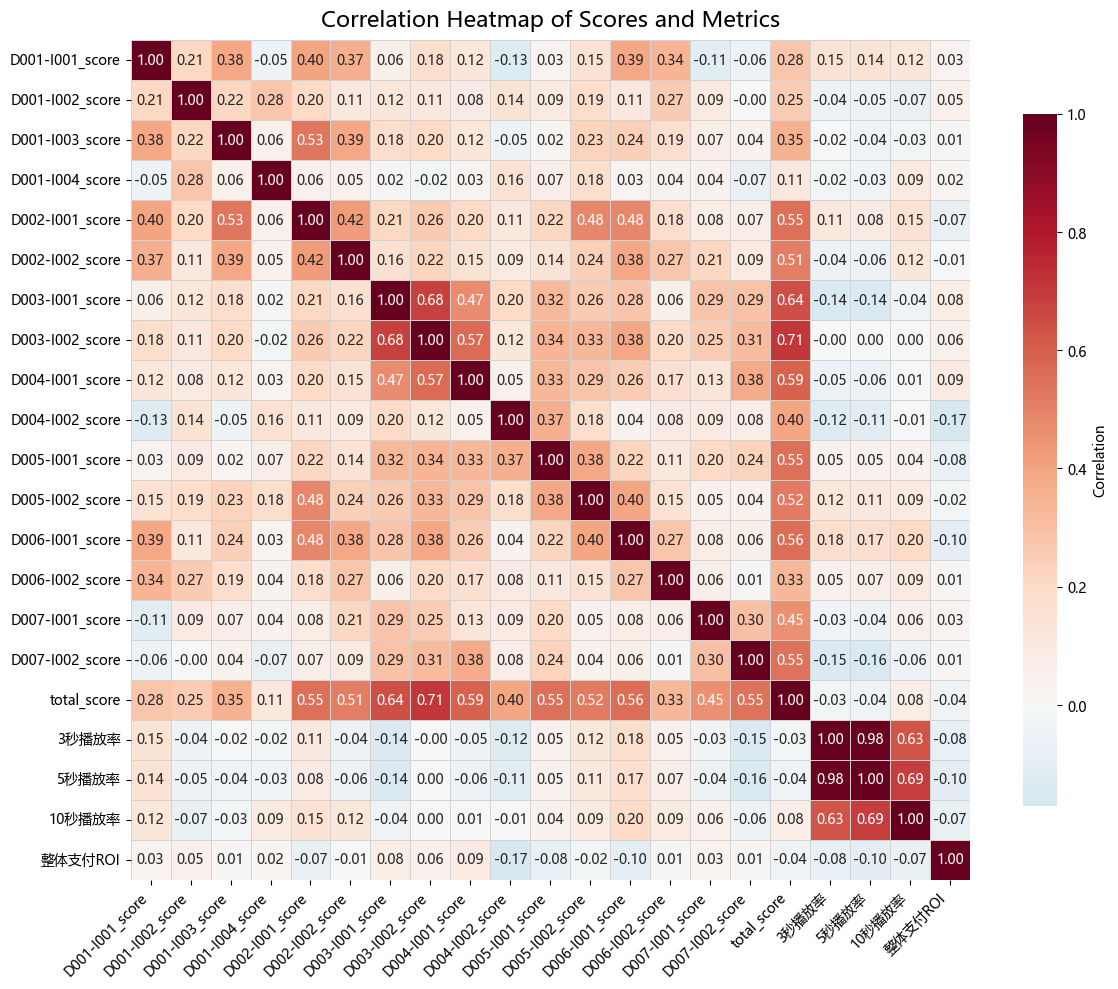

In [13]:
doubao_analysis_result_full_df['video_id'] = doubao_analysis_result_full_df['video_id'].astype('Int64')
score_cols = [
    col
    for col in doubao_analysis_result_full_df.columns
    if ('score' in col) and ('basis' not in col)
].copy()
score_cols = sorted(score_cols)

heatmap_df = pd.merge(filtered_df,doubao_analysis_result_full_df, left_on="素材ID", right_on="video_id", how="inner")
keep_col = score_cols + ['3秒播放率', '5秒播放率', '10秒播放率','整体支付ROI']
scaler = StandardScaler() # 标准化
heatmap_df_scaled = heatmap_df.copy()
heatmap_df_scaled[keep_col] = scaler.fit_transform(heatmap_df_scaled[keep_col])

plt.figure(figsize=(12,10))
cmap_choice = 'RdBu_r' 
ax = sns.heatmap(
    heatmap_df_scaled[keep_col].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap=cmap_choice,
    center=0,            # 关键：让 0 对应白色（如果是发散色系）
    linewidths=0.5,      # 单元格间隔
    linecolor='lightgray', # 间隔线颜色淡一点
    square=True,         # 让每个格子是正方形
    cbar_kws={'shrink': 0.8, 'label': 'Correlation'} # 颜色条缩小一点，更精致
)

plt.title("Correlation Heatmap of Scores and Metrics",fontsize = 16 ,pad=10)
plt.xticks(rotation=45, ha='right')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(MID_TERM_CHARTS_DIR, "Doubao_Rating_Metrics_Correlation_Heatmap.png"), dpi=900)
plt.show()

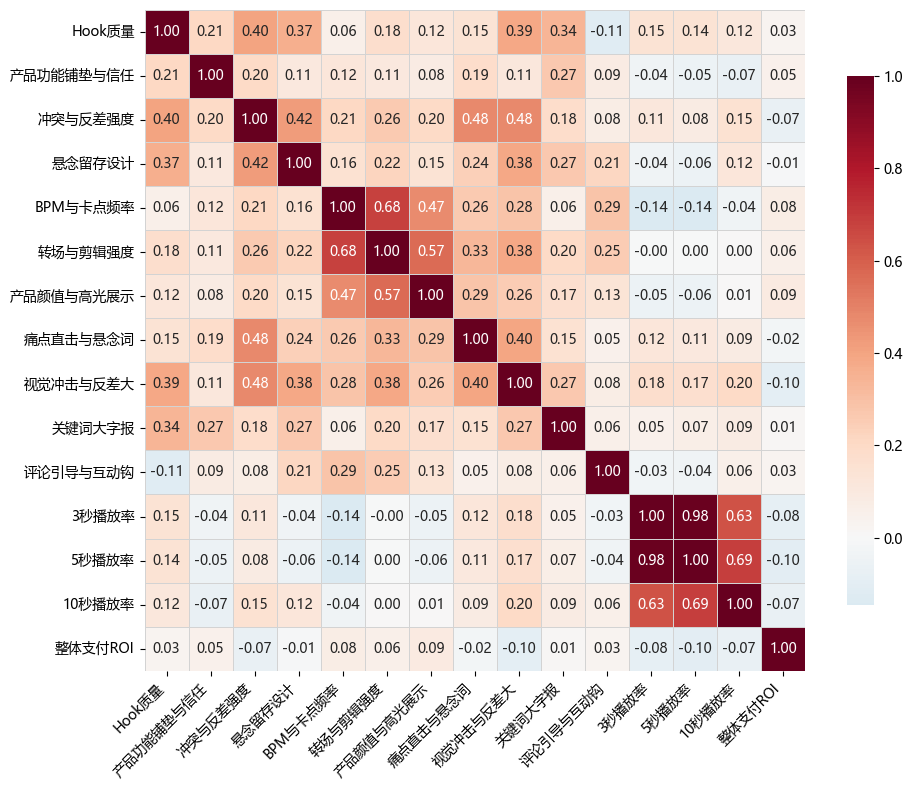

In [14]:
# 完播率相关指标（7个）
completion_rate_indicators = [
    "D001-I001_score",
    "D002-I001_score",
    "D002-I002_score",
    "D003-I001_score",
    "D005-I002_score",
    "D006-I001_score",
    "D006-I002_score"
]

# ROI/下单相关指标（4个）
roi_indicators = [
    "D001-I002_score",
    "D003-I002_score",
    "D004-I001_score",
    "D007-I001_score"
]

full_useful_indicators = sorted(completion_rate_indicators + roi_indicators)

# 简洁版（只保留指标名称）
completion_rate_dict_simple = {
    "D001-I001_score": "Hook质量",
    "D002-I001_score": "冲突与反差强度",
    "D002-I002_score": "悬念留存设计",
    "D003-I001_score": "BPM与卡点频率",
    "D005-I002_score": "痛点直击与悬念词",
    "D006-I001_score": "视觉冲击与反差大",
    "D006-I002_score": "关键词大字报"
}

roi_dict_simple = {
    "D001-I002_score": "产品功能铺垫与信任",
    "D003-I002_score": "转场与剪辑强度",
    "D004-I001_score": "产品颜值与高光展示",
    "D007-I001_score": "评论引导与互动钩"
}

full_useful_indicators_simple = [completion_rate_dict_simple.get(ind, ind) for ind in full_useful_indicators]

heatmap_df_filtered = heatmap_df_scaled[full_useful_indicators + ['3秒播放率', '5秒播放率', '10秒播放率','整体支付ROI']]
heatmap_df_filtered = heatmap_df_filtered.rename(columns={**completion_rate_dict_simple, **roi_dict_simple})
plt.figure(figsize=(10,8))
ax = sns.heatmap(
    heatmap_df_filtered.corr(), 
    annot=True, 
    fmt=".2f", 
    cmap=cmap_choice,
    center=0,
    linewidths=0.5,
    linecolor='lightgray',
    square=True,
    cbar_kws={'shrink': 0.8}
)
# plt.title("Correlation Heatmap of Key Scores and Metrics", fontsize=16, pad=10)
plt.xticks(rotation=45, ha='right')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(MID_TERM_CHARTS_DIR, "Doubao_Key_Rating_Metrics_Correlation_Heatmap.png"), dpi=900)
plt.show()

In [15]:
# 完播率相关指标（7个）
completion_rate_indicators = [
    "D001-I001_score",
    "D002-I001_score",
    "D002-I002_score",
    "D003-I001_score",
    "D005-I002_score",
    "D006-I001_score",
    "D006-I002_score"
]

# ROI/下单相关指标（4个）
roi_indicators = [
    "D001-I002_score",
    "D003-I002_score",
    "D004-I001_score",
    "D007-I001_score"
]

# ============ 对每个指标筛选高于平均分的视频 ============
# 完播率相关指标的高分理由
completion_rate_reasons = hfc.get_high_score_reasons(
    doubao_analysis_result_full_df, 
    completion_rate_indicators
)

# ROI相关指标的高分理由
roi_reasons = hfc.get_high_score_reasons(
    doubao_analysis_result_full_df, 
    roi_indicators
)

# 合并所有指标
all_indicators = completion_rate_indicators + roi_indicators
all_reasons = hfc.get_high_score_reasons(
    doubao_analysis_result_full_df, 
    all_indicators
)


# ============ 打印统计信息 ============

print("=" * 80)
print("完播率相关指标分析")
print("=" * 80)
for base_id, info in completion_rate_reasons.items():
    print(f"\n【{info['indicator_name']}】({base_id})")
    print(f"  平均分: {info['avg_score']} / 7.0")
    print(f"  高于平均分的视频数: {info['high_score_count']}")
    print(f"  示例理由:")
    for i, video in enumerate(info['high_score_videos'][:3]):  # 只显示前3个
        print(f"    [{i+1}] 视频 {video['video_id']} (得分: {video['score']}): {video['reason'][:100]}...")

print("\n" + "=" * 80)
print("ROI相关指标分析")
print("=" * 80)
for base_id, info in roi_reasons.items():
    print(f"\n【{info['indicator_name']}】({base_id})")
    print(f"  平均分: {info['avg_score']} / 7.0")
    print(f"  高于平均分的视频数: {info['high_score_count']}")
    print(f"  示例理由:")
    for i, video in enumerate(info['high_score_videos'][:3]):
        print(f"    [{i+1}] 视频 {video['video_id']} (得分: {video['score']}): {video['reason'][:100]}...")


# ============ 导出为JSON ============
# 导出完播率分析结果
with open(os.path.join(KNOWLEDGE_DIR, 'completion_rate_high_score_reasons.json'), 'w', encoding='utf-8') as f:
    json.dump(completion_rate_reasons, f, ensure_ascii=False, indent=2)

# 导出ROI分析结果
with open(os.path.join(KNOWLEDGE_DIR, 'roi_high_score_reasons.json'), 'w', encoding='utf-8') as f:
    json.dump(roi_reasons, f, ensure_ascii=False, indent=2)

# 导出全部指标
with open(os.path.join(KNOWLEDGE_DIR, 'all_high_score_reasons.json'), 'w', encoding='utf-8') as f:
    json.dump(all_reasons, f, ensure_ascii=False, indent=2)

print("\n" + "=" * 80)
print("结果已导出为JSON文件")
print("  - completion_rate_high_score_reasons.json")
print("  - roi_high_score_reasons.json")
print("  - all_high_score_reasons.json")


# ============ 生成DataFrame ============
# 生成详细的DataFrame
completion_rate_df = hfc.create_analysis_dataframe(completion_rate_reasons)
roi_df = hfc.create_analysis_dataframe(roi_reasons)
all_df = hfc.create_analysis_dataframe(all_reasons)

# 导出为CSV
completion_rate_df.to_csv(os.path.join(KNOWLEDGE_DIR, 'completion_rate_high_score_details.csv'), index=False, encoding='utf-8-sig')
roi_df.to_csv(os.path.join(KNOWLEDGE_DIR, 'roi_high_score_details.csv'), index=False, encoding='utf-8-sig')
all_df.to_csv(os.path.join(KNOWLEDGE_DIR, 'all_high_score_details.csv'), index=False, encoding='utf-8-sig')

print("\n详细数据已导出为CSV文件")

完播率相关指标分析

【Hook (0-3秒)】(D001-I001)
  平均分: 5.9 / 7.0
  高于平均分的视频数: 143
  示例理由:
    [1] 视频 7560476177228988435 (得分: 6): 开头直接抛出高端影音设备价格问题，快速抓注意力...
    [2] 视频 7552688222016684071 (得分: 6): 开头直接抛出家庭KTV安装疑问，吸引目标用户...
    [3] 视频 7560103525498896393 (得分: 6): 0秒抛出功能+价格疑问，快速抓取用户注意力...

【冲突与反差强度】(D002-I001)
  平均分: 5.74 / 7.0
  高于平均分的视频数: 149
  示例理由:
    [1] 视频 7560103525498896393 (得分: 6): 打破高端影音设备昂贵的认知，反差明显...
    [2] 视频 7570718436512120868 (得分: 6): 认知反差：别墅高端设备实际价格低功能全...
    [3] 视频 7559000042486005796 (得分: 6): 对比传统旧设备落后与新品优势，认知反差明显...

【悬念留存设计】(D002-I002)
  平均分: 5.49 / 7.0
  高于平均分的视频数: 104
  示例理由:
    [1] 视频 7560476177228988435 (得分: 6): 开头抛出价格问题，引导用户等待最终答案...
    [2] 视频 7552688222016684071 (得分: 6): 开头抛出价格、安装疑问，引导用户等待答案...
    [3] 视频 7560103525498896393 (得分: 6): 开头抛价格疑问，后续逐步揭晓引导完播...

【BPM与卡点频率】(D003-I001)
  平均分: 5.44 / 7.0
  高于平均分的视频数: 89
  示例理由:
    [1] 视频 7560103525498896393 (得分: 6): BGM适配带货节奏，剪辑卡点准确观感流畅...
    [2] 视频 7570718436512120868 (得分: 6): 带货节奏明快，BGM适配，剪辑卡点准确...
    [3] 视频 7568644679476

In [16]:
from openai import OpenAI
# 初始化OpenAI客户端
OPENAI_BASE_URL = "https://ai.ktokenhub.app/v1"
OPENAI_MODEL = "gpt-5.5"
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise RuntimeError("Please set OPENAI_API_KEY before running this script.")

openai_client = OpenAI(
    api_key=OPENAI_API_KEY,
    base_url=OPENAI_BASE_URL,
)

def call_openai_for_summary(prompt_template: str, json_data, model: str = OPENAI_MODEL):
    """
    调用OpenAI API生成知识库总结
    """
    # 格式化JSON数据
    json_str = json.dumps(json_data, ensure_ascii=False, indent=2)
    
    # 使用 replace 代替 format，避免花括号冲突
    full_prompt = prompt_template.replace("{json_data}", json_str)
    
    # 调用OpenAI
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "你是一位专业的短视频内容策略专家，擅长从数据中提取可操作的洞察。请严格按照JSON格式输出。"},
            {"role": "user", "content": full_prompt}
        ],
        temperature=0.7,
        # response_format={"type": "json_object"}  # 先注释掉，确保兼容性
    )
    
    # 提取响应内容
    content = response.choices[0].message.content
    
    # 解析JSON
    try:
        # 尝试提取 JSON 部分（处理可能的 markdown 代码块）
        if content.startswith("```json"):
            content = content[7:-3]
        elif content.startswith("```"):
            content = content[3:-3]
        
        result = json.loads(content)
        return result
    except json.JSONDecodeError as e:
        print(f"JSON解析失败: {e}")
        print(f"原始响应: {content[:500]}...")
        # 尝试提取JSON部分
        import re
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        if json_match:
            return json.loads(json_match.group())
        raise

# 生成知识库
def generate_single_knowledge_base(data_file: str, output_file: str, prompt_template: str):
    """单独生成一个知识库"""
    data = hfc.load_json_data(data_file)
    knowledge_base = call_openai_for_summary(prompt_template, data)
    hfc.save_knowledge_base(knowledge_base, output_file)
    return knowledge_base

# generate_single_knowledge_base(os.path.join(KNOWLEDGE_DIR, 'completion_rate_high_score_reasons.json'),
#                               os.path.join(KNOWLEDGE_DIR, 'completion_rate_knowledge_base.json'),
#                               PromptTemplate.COMPLETION_RATE_SUMMARY_PROMPT)
# generate_single_knowledge_base(os.path.join(KNOWLEDGE_DIR, 'roi_high_score_reasons.json'),
#                               os.path.join(KNOWLEDGE_DIR, 'roi_knowledge_base.json'),
#                               PromptTemplate.ROI_SUMMARY_PROMPT)
    
hfc.print_knowledge_base_summary(
    hfc.load_json_data(os.path.join(KNOWLEDGE_DIR, 'completion_rate_knowledge_base.json')),
    "完播率提升知识库")

hfc.print_knowledge_base_summary(
    hfc.load_json_data(os.path.join(KNOWLEDGE_DIR, 'completion_rate_knowledge_base.json')),
    "完播率提升知识库")


完播率提升知识库 - 知识库摘要

核心洞察: 完播率的核心秘诀是：在0-3秒用醒目视觉和强痛点话术抛出价格、替代方案或利益悬念，再用反差、逐步揭秘和紧凑节奏持续兑现用户好奇心。

关键发现: 从高分视频评分理由看，完播率表现好的内容高度集中在“开头即给冲突/利益点”的结构上：价格疑问、传统设备落后、闲置电视改造、把KTV搬回家、别墅级设备低价等主题反复出现，并且通常配合黄色超大字幕、人物主体、核心问题大字报，让用户在静音状态下也能立刻理解看点。
另一个重要规律是，高完播视频不是单靠一个钩子，而是把“痛点词+认知反差+价格悬念+节奏卡点”组合使用。例如先用“千万不要装传统点歌机”“别花冤枉钱”“电视闲置太浪费”等强情绪词制造停留，再用传统复杂设备与小巧一体机、外出KTV高消费与居家低成本、别墅级场景与亲民价格的反差维持兴趣，最后通过功能展示和价格后置揭晓推动用户看完。

指标概览:
  - Hook (0-3秒): 平均分 5.9
    成功模式: 0秒或首秒直接抛出价格问题，如家庭KTV多少钱、影音设备多少钱、别墅级音响多少钱，快速抓住价格敏感用户。, 开头直接否定旧方案或传统设备，如“别装传统点歌机”“不要买旧K歌设备”“传统K歌设备太落后”，制造认知冲突。
  - 冲突与反差强度: 平均分 5.74
    成功模式: 高端场景与低价形成反差，如别墅级设备、家庭影院、KTV级效果，却价格亲民。, 传统多设备、笨重复杂方案与小巧一体机形成反差。
  - 悬念留存设计: 平均分 5.49
    成功模式: 开头抛价格问题，后半段或最后揭晓最终价格。, 开头否定旧方案，但暂不说新方案，制造“那用什么”的悬念。
  - BPM与卡点频率: 平均分 5.44
    成功模式: 使用适配带货场景的快节奏BGM，增强紧凑感。, 口播节奏明快，剪辑与口播内容同步，减少拖沓。
  - 痛点直击与悬念词: 平均分 5.82
    成功模式: 高频痛点包括：KTV消费高、安装麻烦、设备贵、传统设备落后、操作复杂、电视闲置浪费、怕买贵、怕买错、怕错过优惠。, 高频强情绪词包括：千万不要、千万别、太落后、花冤枉钱、亏大了、不要上当、错过、清仓、便宜到不敢想、不买后悔。
  - 视觉冲击与反差大: 平均分 5.55
    成功模式: 首帧使用黄色或红黄色高对比大字，视觉焦点强

## 评分histplots

Saved: ..//Deliverables\Mid-Term\Charts\Doubao_Score_Hist_1-12.png


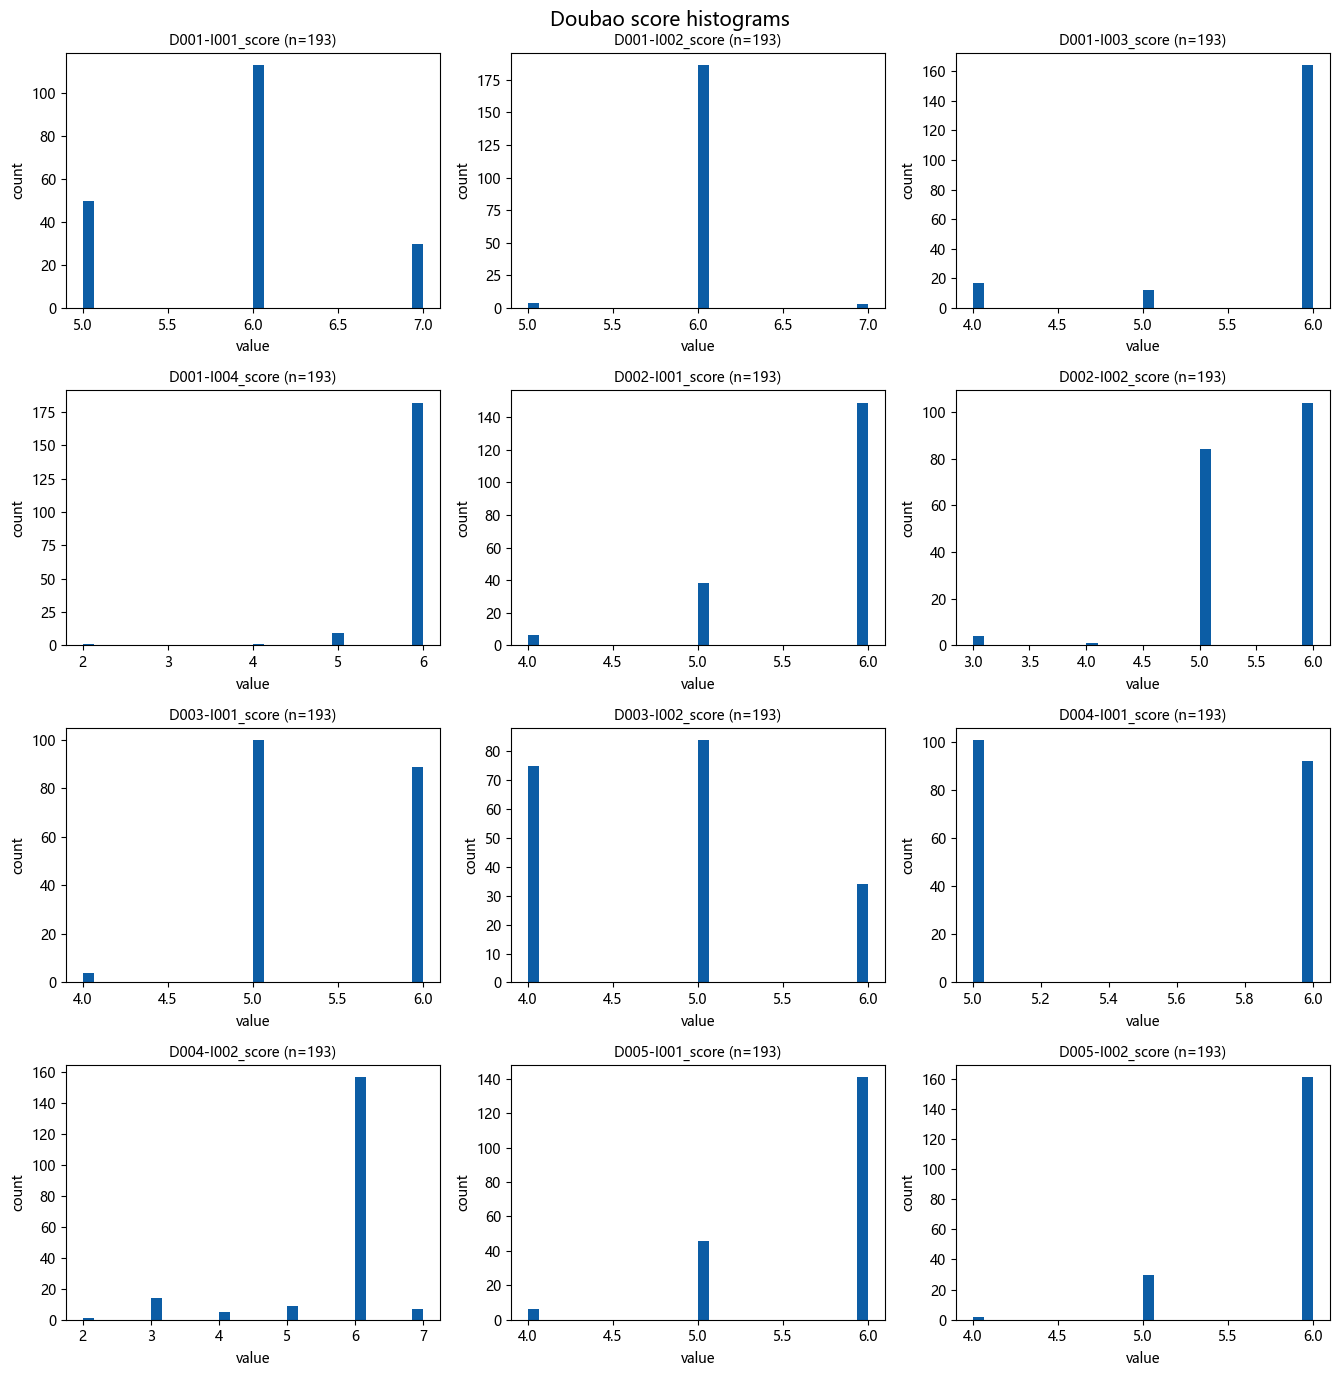

Saved: ..//Deliverables\Mid-Term\Charts\Doubao_Score_Hist_13-17.png


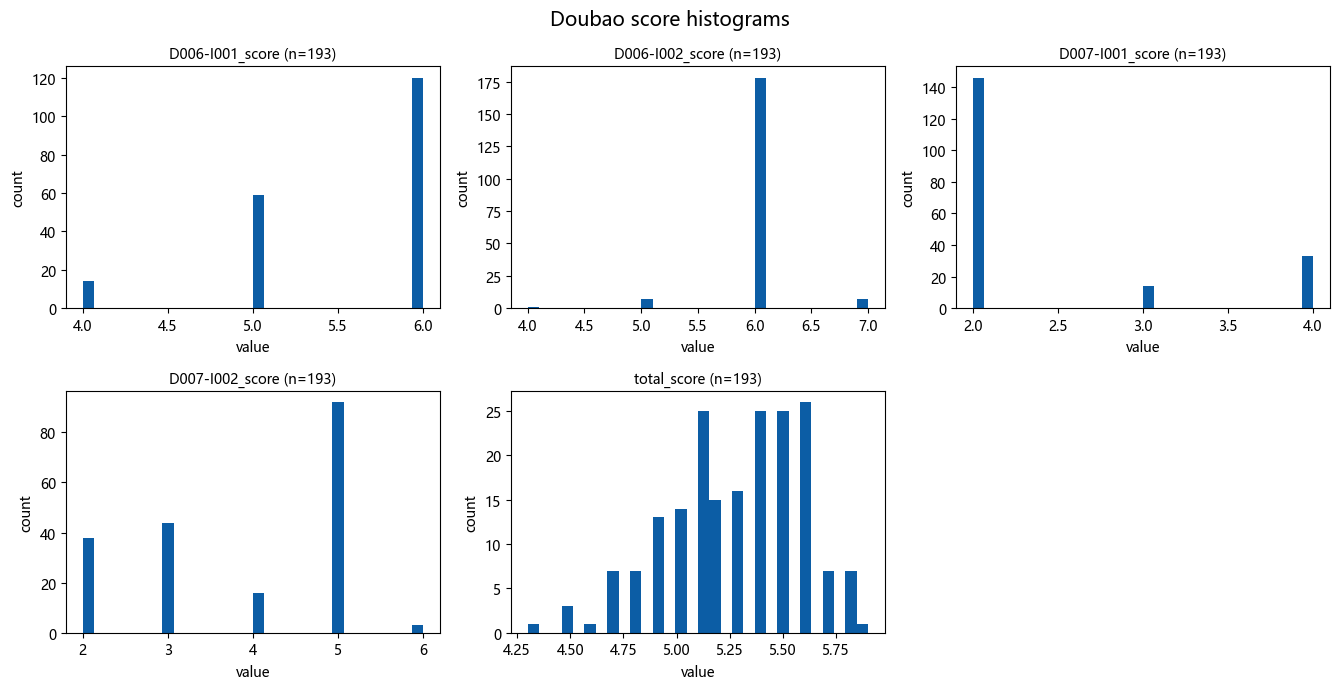

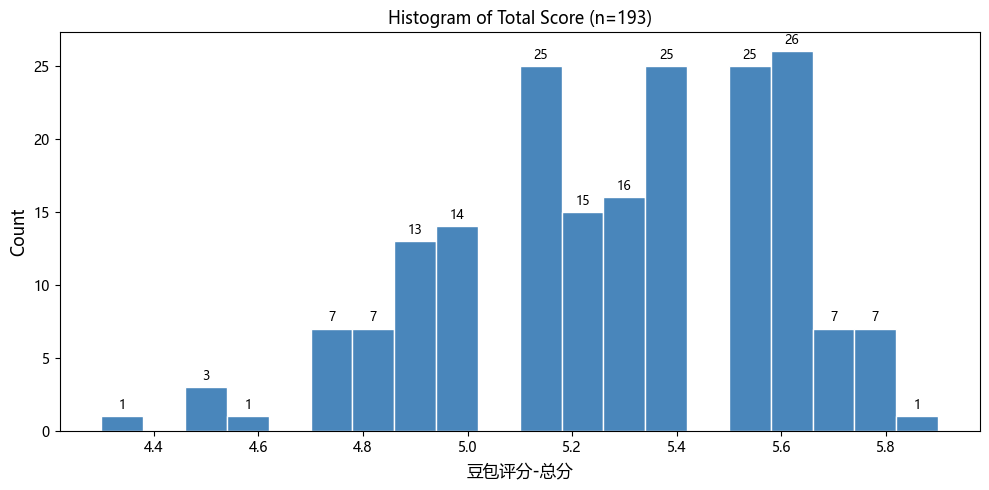

In [18]:
# histplots
plot_df = doubao_analysis_result_full_df[score_cols].apply(pd.to_numeric, errors='coerce')
max_plots_per_fig = 12  # 3x4 per figure
ncols = 3
bins = 30

for start in range(0, len(score_cols), max_plots_per_fig):
    subset = score_cols[start : start + max_plots_per_fig]
    n_sub = len(subset)
    nrows = np.ceil(n_sub / ncols).astype(int)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(ncols * 4.5, nrows * 3.5),
        squeeze=False,
    )
    axes_flat = axes.ravel()
    for ax, col in zip(axes_flat, subset):
        data = plot_df[col].dropna()
        ax.hist(data, bins=bins)
        ax.set_title(f"{col} (n={len(data)})", fontsize=10)
        ax.set_xlabel("value")
        ax.set_ylabel("count")

    for ax in axes_flat[n_sub:]:
        ax.axis('off')

    fig.suptitle("Doubao score histograms", fontsize=14)
    fig.tight_layout()

    if 'MID_TERM_CHARTS_DIR' in globals():
        out_path = os.path.join(
            MID_TERM_CHARTS_DIR, f"Doubao_Score_Hist_{start+1}-{start+n_sub}.png"
        )
        fig.savefig(out_path, dpi=300)
        print("Saved:", out_path)

    plt.show()

# total_score histplot + annotate counts on bars
total_score_s = pd.to_numeric(doubao_analysis_result_full_df['total_score'], errors='coerce').dropna()
if total_score_s.empty:
    raise ValueError("total_score has no valid numeric values after coercion")

# If total_score is basically integers, use integer bins; else use a reasonable fixed bin count
is_integer_like = np.all(np.isclose(total_score_s, np.round(total_score_s)))
if is_integer_like:
    min_v = int(np.floor(total_score_s.min()))
    max_v = int(np.ceil(total_score_s.max()))
    bins = np.arange(min_v - 0.5, max_v + 1.5, 1)
else:
    bins = 20

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(total_score_s, bins=bins, ax=ax, edgecolor='white')
ax.set_title(f"Histogram of Total Score (n={len(total_score_s)})")
ax.set_xlabel('豆包评分-总分', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Annotate bar counts
for patch in ax.patches:
    height = patch.get_height()
    if height <= 0:
        continue
    x = patch.get_x() + patch.get_width() / 2
    ax.annotate(
        f"{int(height)}",
        (x, height),
        xytext=(0, 3),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
fig.savefig(os.path.join(MID_TERM_CHARTS_DIR, "Doubao_total_score_hist_annotated.png"), dpi=300)
plt.show()